In [1]:
# Imports and Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
import warnings
warnings.filterwarnings('ignore')

print("✅ Imports loaded")

c:\Users\hashe\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Imports loaded


In [2]:
# Load Data with error handling
import os

# Paths
EMBEDDINGS_PATH = "../data/embeddings/ticket_embeddings.npy"
METADATA_PATH = "../data/embeddings/ticket_metadata.csv"

# Create directories if they don't exist
os.makedirs("../models", exist_ok=True)
os.makedirs("../results", exist_ok=True)

# Check if file exists
print(f"File exists: {os.path.exists(EMBEDDINGS_PATH)}")
if os.path.exists(EMBEDDINGS_PATH):
    file_size = os.path.getsize(EMBEDDINGS_PATH)
    print(f"File size: {file_size / (1024*1024):.2f} MB")
    
    # Check first few bytes to identify file type
    with open(EMBEDDINGS_PATH, 'rb') as f:
        header = f.read(10)
        print(f"First 10 bytes (hex): {header.hex()}")
        print(f"First 10 bytes (repr): {header}")

# Load embeddings with memory mapping
try:
    print("\nTrying to load with mmap_mode='r'...")
    embeddings = np.load(EMBEDDINGS_PATH, mmap_mode='r')
    print(f"✅ Embeddings memmap shape: {embeddings.shape}")
except Exception as e:
    print(f"Failed to load embeddings as memmap: {e}")
    try:
        print("\nTrying to load without mmap_mode...")
        embeddings = np.load(EMBEDDINGS_PATH, allow_pickle=False)
        print(f"✅ Loaded embeddings shape: {embeddings.shape}")
    except Exception as e2:
        print(f"Failed to load embeddings: {e2}")
        embeddings = None

# Load metadata
print("\nLoading metadata...")
metadata = pd.read_csv(METADATA_PATH)
print(f"✅ Metadata shape: {metadata.shape}")

# Display category distribution
print("\n=== Category Distribution ===")
print(metadata['Issue_Category'].value_counts())

File exists: True
File size: 508.08 MB
First 10 bytes (hex): 934e554d505901007600
First 10 bytes (repr): b'\x93NUMPY\x01\x00v\x00'

Trying to load with mmap_mode='r'...
✅ Embeddings memmap shape: (346851, 384)

Loading metadata...
✅ Metadata shape: (346851, 2)

=== Category Distribution ===
Issue_Category
Account            122410
Technical           83295
General Inquiry     70476
Billing             58129
Fraud               12541
Name: count, dtype: int64


In [3]:
# Explore Data Statistics
print("=== DATA STATISTICS ===\n")
print(f"Total tickets: {len(metadata):,}")
print(f"Unique categories: {metadata['Issue_Category'].nunique()}")

if embeddings is not None:
    print(f"Embedding dimension: {embeddings.shape[1]}")
    print(f"Embedding dtype: {embeddings.dtype}")

    # Memory usage calculation
    try:
        mem_usage = embeddings.size * embeddings.itemsize / (1024**3)
        print(f"\nMemory usage (if loaded fully): {mem_usage:.2f} GB")
    except Exception:
        print("\nMemory usage: unknown")
    print("Memory-mapped mode: Active (using disk, not RAM)")

    # Sample some embeddings
    print("\nSample embedding for first ticket:")
    print(f"Shape: {embeddings[0].shape}")
    print(f"First 10 values: {embeddings[0][:10]}")
    print(f"Min value: {embeddings[0].min():.4f}")
    print(f"Max value: {embeddings[0].max():.4f}")
    print(f"Mean value: {embeddings[0].mean():.4f}")
else:
    print("Embeddings are not available for statistics.")

=== DATA STATISTICS ===

Total tickets: 346,851
Unique categories: 5
Embedding dimension: 384
Embedding dtype: float32

Memory usage (if loaded fully): 0.50 GB
Memory-mapped mode: Active (using disk, not RAM)

Sample embedding for first ticket:
Shape: (384,)
First 10 values: [-0.00245065 -0.01031996  0.04242312  0.02304375 -0.02096345 -0.02881619
  0.00487326 -0.03328269 -0.044471   -0.02217819]
Min value: -0.1624
Max value: 0.1615
Mean value: 0.0003


In [4]:
# Load Full Embeddings Dataset
import gc

print(f"Metadata shape: {metadata.shape}")
print(f"Embeddings shape: {embeddings.shape}")

# Use all available data
actual_size = embeddings.shape[0]
print(f"\nUsing all {actual_size:,} embeddings")

# Trim metadata to match
if len(metadata) > actual_size:
    metadata = metadata.iloc[:actual_size]
    print(f"✅ Trimmed metadata to {actual_size:,} rows")

# Use the full dataset via memmap
USE_FULL_DATA = True

if USE_FULL_DATA:
    print("\nUsing the full memory-mapped dataset.")
    X_large = embeddings
    y_large = metadata['Issue_Category'].values
    print(f"✅ X_large is a memmap with shape: {X_large.shape}")

    # Create train/test split indices
    all_indices = np.arange(actual_size)
    train_indices, test_indices = train_test_split(
        all_indices,
        test_size=0.2,
        stratify=y_large,
        random_state=42
    )
    print(f"✅ Train indices: {len(train_indices):,}, Test indices: {len(test_indices):,}")
else:
    SAMPLE_SIZE = 98110
    print(f"\nLoading a stratified sample of {SAMPLE_SIZE:,} embeddings into RAM...")
    _, sample_indices = train_test_split(
        range(actual_size),
        test_size=SAMPLE_SIZE,
        stratify=metadata['Issue_Category'],
        random_state=42
    )
    X_large = np.array([embeddings[i] for i in sample_indices], dtype=np.float32)
    y_large = metadata.iloc[sample_indices]['Issue_Category'].values
    print(f"✅ X_large shape: {X_large.shape}")
    print(f"✅ Memory usage: {X_large.nbytes / (1024**3):.2f} GB")

    train_indices, test_indices = train_test_split(
        np.arange(len(sample_indices)),
        test_size=0.2,
        stratify=np.array(y_large),
        random_state=42
    )

# Encode labels
label_encoder = LabelEncoder()
y_large_encoded = label_encoder.fit_transform(y_large)
class_names = label_encoder.classes_

print(f"\nClasses: {len(class_names)}")
print("Class distribution:")
for i, class_name in enumerate(class_names):
    count = sum(y_large_encoded == i)
    print(f"  {class_name}: {count:,} ({count/len(y_large_encoded)*100:.1f}%)")

# Split for training (80/20)
if USE_FULL_DATA:
    X_train_indices = train_indices
    X_test_indices = test_indices
    y_train = y_large_encoded[X_train_indices]
    y_test = y_large_encoded[X_test_indices]
    print(f"\nUsing index-based train/test split with {len(X_train_indices):,} train and {len(X_test_indices):,} test samples.")
    X_train = None
    X_test = None
else:
    X_train, X_test, y_train, y_test = train_test_split(
        X_large,
        y_large_encoded,
        test_size=0.2,
        random_state=42,
        stratify=y_large_encoded
    )
    print(f"\nTrain size: {len(X_train):,}")
    print(f"Test size: {len(X_test):,}")

# Free some memory
if not USE_FULL_DATA:
    del embeddings
gc.collect()

Metadata shape: (346851, 2)
Embeddings shape: (346851, 384)

Using all 346,851 embeddings

Using the full memory-mapped dataset.
✅ X_large is a memmap with shape: (346851, 384)
✅ Train indices: 277,480, Test indices: 69,371

Classes: 5
Class distribution:
  Account: 122,410 (35.3%)
  Billing: 58,129 (16.8%)
  Fraud: 12,541 (3.6%)
  General Inquiry: 70,476 (20.3%)
  Technical: 83,295 (24.0%)

Using index-based train/test split with 277,480 train and 69,371 test samples.


100

In [5]:
# Train Multiple Classifiers on Larger Sample
import time

# If using the full memmap dataset, sample a manageable subset for classifier training
if USE_FULL_DATA:
    MODEL_SAMPLE_SIZE = 346851
    print(f"\nUsing a sampled subset of {MODEL_SAMPLE_SIZE:,} train samples from the full memmap dataset for training.")
    if len(X_train_indices) > MODEL_SAMPLE_SIZE:
        sampled_train_indices = np.random.choice(X_train_indices, size=MODEL_SAMPLE_SIZE, replace=False)
    else:
        sampled_train_indices = X_train_indices

    sampled_test_size = min(len(X_test_indices), MODEL_SAMPLE_SIZE // 5)
    if len(X_test_indices) > sampled_test_size:
        sampled_test_indices = np.random.choice(X_test_indices, size=sampled_test_size, replace=False)
    else:
        sampled_test_indices = X_test_indices

    X_train = X_large[sampled_train_indices]
    X_test = X_large[sampled_test_indices]
    y_train = y_large_encoded[sampled_train_indices]
    y_test = y_large_encoded[sampled_test_indices]
    print(f"✅ Sampled X_train shape: {X_train.shape}")
    print(f"✅ Sampled X_test shape: {X_test.shape}")

# Define classifiers
classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1),
    'Linear SVM': LinearSVC(max_iter=1000, random_state=42, dual='auto'),
    'KNN (k=10)': KNeighborsClassifier(n_neighbors=10, n_jobs=-1),
    'Random Forest (200)': RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
}

results_large = []

print(f"Training on {len(X_train):,} samples with {len(class_names)} classes...\n")

for name, clf in classifiers.items():
    print(f"Training {name}...")
    start_time = time.time()
    
    try:
        clf.fit(X_train, y_train)
        train_time = time.time() - start_time
        
        # Predict on test set
        print(f"  Predicting on {len(X_test):,} samples...")
        y_pred = clf.predict(X_test)
        
        acc = accuracy_score(y_test, y_pred)
        results_large.append({
            'Classifier': name,
            'Accuracy': acc,
            'Train_Time': train_time,
            'Predictions': y_pred,
            'Model': clf
        })
        print(f"  Accuracy: {acc:.4f}")
        print(f"  Time: {train_time:.2f} seconds\n")
        
    except Exception as e:
        print(f"  Error: {e}\n")

# Display results
results_df_large = pd.DataFrame(results_large)
print("\n=== RESULTS (Large Sample) ===")
print(results_df_large[['Classifier', 'Accuracy', 'Train_Time']].sort_values('Accuracy', ascending=False))


Using a sampled subset of 346,851 train samples from the full memmap dataset for training.
✅ Sampled X_train shape: (277480, 384)
✅ Sampled X_test shape: (69370, 384)
Training on 277,480 samples with 5 classes...

Training Logistic Regression...
  Predicting on 69,370 samples...
  Accuracy: 0.7796
  Time: 71.09 seconds

Training Linear SVM...
  Predicting on 69,370 samples...
  Accuracy: 0.7762
  Time: 121.90 seconds

Training KNN (k=10)...
  Predicting on 69,370 samples...
  Accuracy: 0.7639
  Time: 0.08 seconds

Training Random Forest (200)...
  Predicting on 69,370 samples...
  Accuracy: 0.7292
  Time: 150.61 seconds


=== RESULTS (Large Sample) ===
            Classifier  Accuracy  Train_Time
0  Logistic Regression  0.779573   71.094347
1           Linear SVM  0.776229  121.895420
2           KNN (k=10)  0.763904    0.075739
3  Random Forest (200)  0.729206  150.608513


Best Classifier: Logistic Regression
Accuracy: 0.7796

Classification Report:
                 precision    recall  f1-score   support

        Account       0.82      0.86      0.84     24482
        Billing       0.80      0.75      0.77     11626
          Fraud       0.66      0.34      0.45      2508
General Inquiry       0.72      0.74      0.73     14096
      Technical       0.76      0.78      0.77     16658

       accuracy                           0.78     69370
      macro avg       0.75      0.70      0.71     69370
   weighted avg       0.78      0.78      0.78     69370



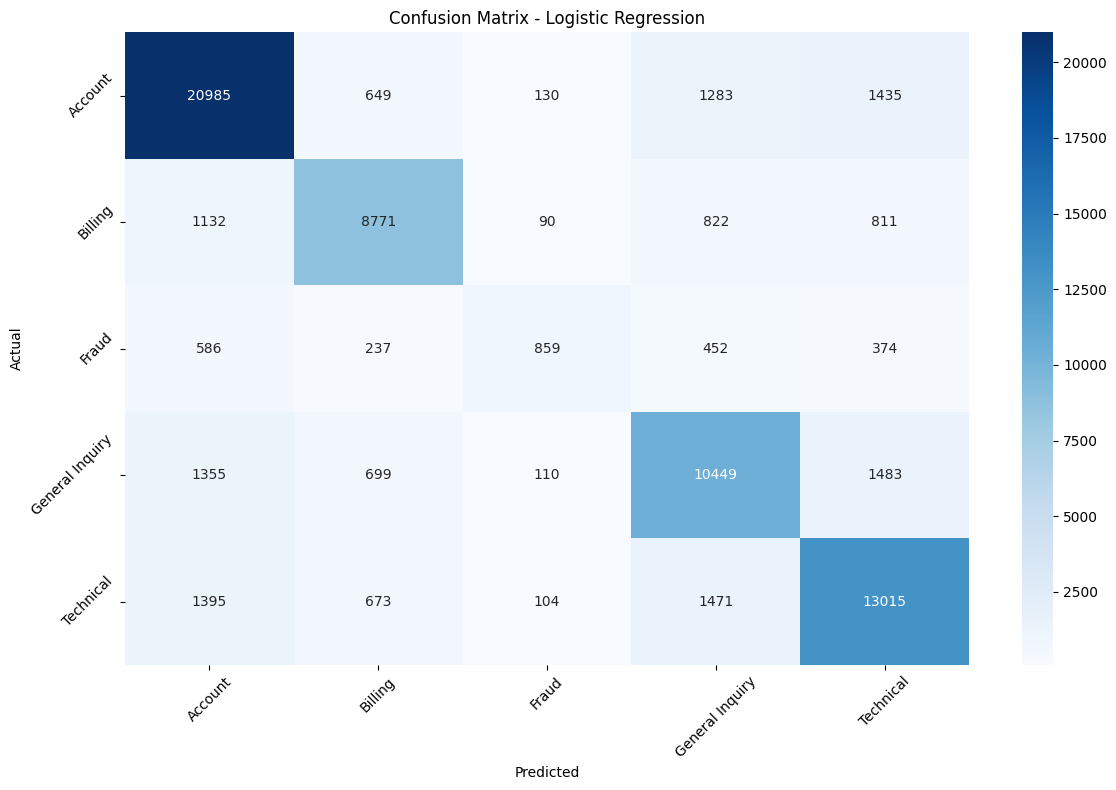

In [6]:
# Best Model Detailed Report
# Get best model
best_result = max(results_large, key=lambda x: x['Accuracy'])
best_clf_name = best_result['Classifier']
best_y_pred = best_result['Predictions']
best_clf = best_result['Model']

print(f"Best Classifier: {best_clf_name}")
print(f"Accuracy: {best_result['Accuracy']:.4f}\n")

# Classification report
print("Classification Report:")
print(classification_report(y_test, best_y_pred, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(y_test, best_y_pred)
plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title(f'Confusion Matrix - {best_clf_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.tight_layout()
plt.show()

Selecting a sample for dimensionality reduction...
Performing PCA...
Explained variance ratio (first 50 components): 0.6075

Performing t-SNE on 5000 samples...


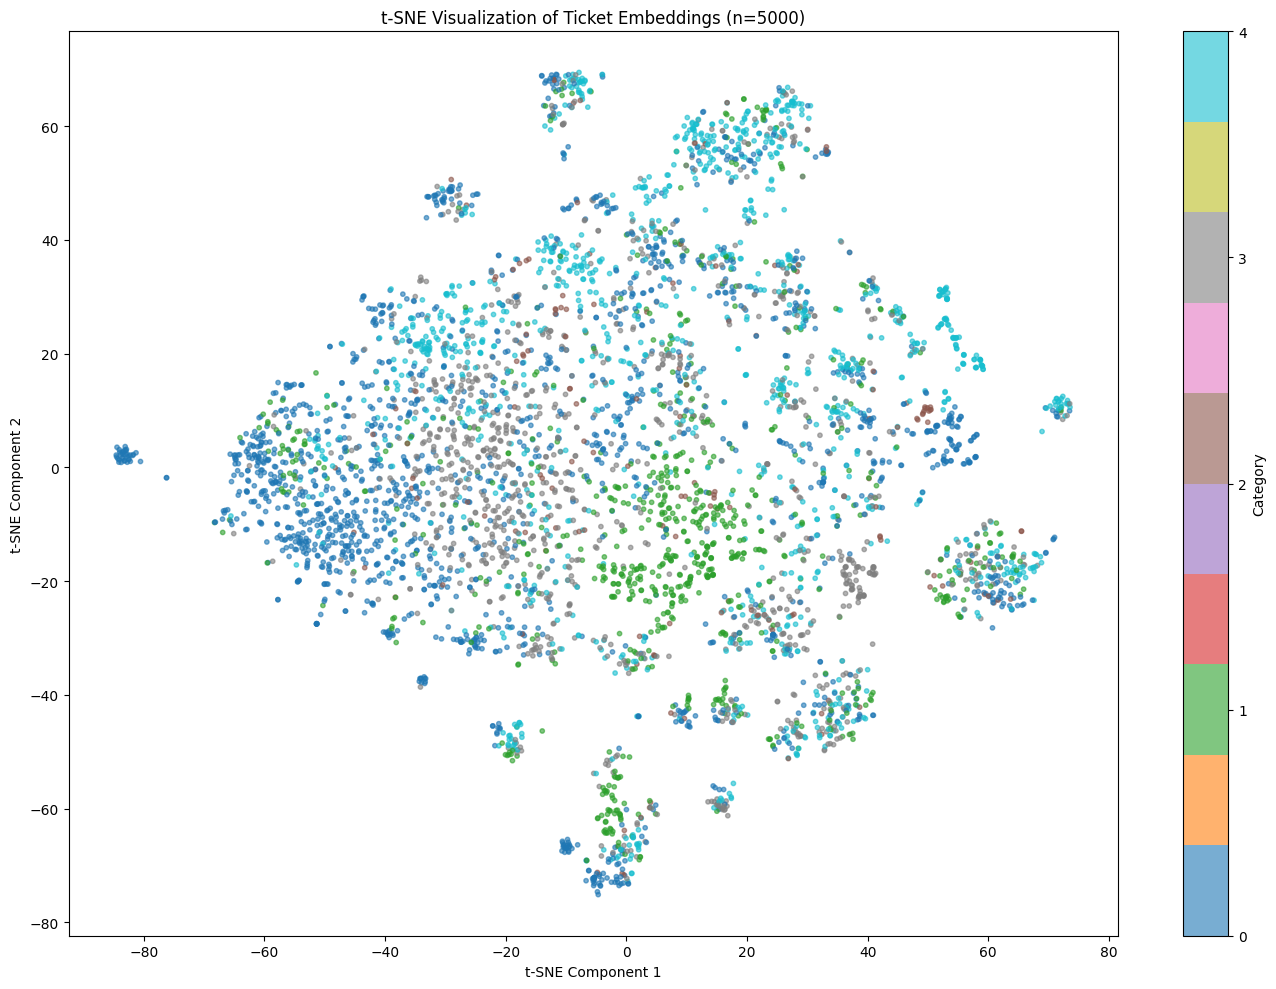

In [7]:
# Dimensionality Reduction for Visualization
print("Selecting a sample for dimensionality reduction...")
sample_size = min(5000, len(X_large))
sample_indices = np.random.choice(len(X_large), sample_size, replace=False)
X_vis = X_large[sample_indices]
y_sample = y_large_encoded[sample_indices]

print("Performing PCA...")
pca = PCA(n_components=50)
X_pca = pca.fit_transform(X_vis)
print(f"Explained variance ratio (first 50 components): {pca.explained_variance_ratio_.sum():.4f}")

print(f"\nPerforming t-SNE on {sample_size} samples...")
# Fixed: use max_iter instead of n_iter
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
X_tsne = tsne.fit_transform(X_pca)

# Plot t-SNE
plt.figure(figsize=(14, 10))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], 
                      c=y_sample, cmap='tab10', alpha=0.6, s=10)
plt.colorbar(scatter, ticks=range(len(class_names)), label='Category')
plt.title(f't-SNE Visualization of Ticket Embeddings (n={sample_size})')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.tight_layout()
plt.show()

In [8]:
# Similar Ticket Search (RAG-style)
def find_similar_tickets(ticket_idx, embeddings, metadata, top_k=5):
    """
    Find similar tickets to a given ticket index
    """
    query_embedding = embeddings[ticket_idx].reshape(1, -1)
    
    # Calculate cosine similarity
    similarities = cosine_similarity(query_embedding, embeddings)[0]
    
    # Get top k (excluding itself)
    similar_indices = np.argsort(similarities)[::-1][1:top_k+1]
    similar_scores = similarities[similar_indices]
    
    # Display results
    print(f"\n=== Similar tickets to Ticket #{ticket_idx} ===")
    print(f"Original ticket category: {metadata.iloc[ticket_idx]['Issue_Category']}\n")
    
    for i, (idx, score) in enumerate(zip(similar_indices, similar_scores), 1):
        print(f"{i}. Ticket #{idx}")
        print(f"   Category: {metadata.iloc[idx]['Issue_Category']}")
        print(f"   Similarity score: {score:.4f}")
        print()

# Test similarity search
print("Testing similarity search...")
test_indices = [0, 100, 1000, 5000]
for idx in test_indices:
    if idx < len(metadata):
        find_similar_tickets(idx, embeddings, metadata, top_k=3)

Testing similarity search...

=== Similar tickets to Ticket #0 ===
Original ticket category: General Inquiry

1. Ticket #7679
   Category: General Inquiry
   Similarity score: 0.9154

2. Ticket #7851
   Category: General Inquiry
   Similarity score: 0.8632

3. Ticket #15419
   Category: General Inquiry
   Similarity score: 0.8460


=== Similar tickets to Ticket #100 ===
Original ticket category: Technical

1. Ticket #14457
   Category: Technical
   Similarity score: 0.8896

2. Ticket #8401
   Category: Technical
   Similarity score: 0.8856

3. Ticket #8196
   Category: Technical
   Similarity score: 0.8791


=== Similar tickets to Ticket #1000 ===
Original ticket category: Technical

1. Ticket #4368
   Category: Technical
   Similarity score: 0.9422

2. Ticket #7233
   Category: Technical
   Similarity score: 0.9412

3. Ticket #11169
   Category: Technical
   Similarity score: 0.9382


=== Similar tickets to Ticket #5000 ===
Original ticket category: Billing

1. Ticket #14412
   Catego

In [9]:
# Improved Query-based Search with Complex Ticket Queries
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

def clean_query_text(text):
    """Clean query text to match ticket preprocessing"""
    import re
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def search_by_text(query_text, embeddings, metadata, model, top_k=5, use_sample=False, sample_size=10000):
    """
    Search tickets by text query with improved results
    """
    # Clean query
    cleaned_query = clean_query_text(query_text)
    
    # Use sample for faster search (optional)
    if use_sample and len(embeddings) > sample_size:
        sample_indices = np.random.choice(len(embeddings), sample_size, replace=False)
        search_embeddings = embeddings[sample_indices]
        search_metadata = metadata.iloc[sample_indices]
    else:
        search_embeddings = embeddings
        search_metadata = metadata
    
    # Encode query
    query_embedding = model.encode([cleaned_query], convert_to_numpy=True)
    
    # Calculate similarities
    similarities = cosine_similarity(query_embedding, search_embeddings)[0]
    
    # Get top k
    top_indices = np.argsort(similarities)[::-1][:top_k]
    top_scores = similarities[top_indices]
    
    # Display results
    print(f"\n{'='*70}")
    print(f"🔍 Search Results for: '{query_text}'")
    print(f"{'='*70}")
    
    # Show category distribution
    categories = search_metadata.iloc[top_indices]['Issue_Category'].values
    unique, counts = np.unique(categories, return_counts=True)
    print(f"\n📊 Category distribution in top {top_k} results:")
    for cat, count in zip(unique, counts):
        print(f"   {cat}: {count} ({count/top_k*100:.0f}%)")
    
    print(f"\n📋 Top {top_k} similar tickets:")
    print("-" * 70)
    
    for i, (idx, score) in enumerate(zip(top_indices, top_scores), 1):
        # Get the actual text for context
        text_preview = ""
        if 'clean_text' in search_metadata.columns:
            text_preview = str(search_metadata.iloc[idx]['clean_text'])[:150] + "..."
        elif 'text' in search_metadata.columns:
            text_preview = str(search_metadata.iloc[idx]['text'])[:150] + "..."
        
        # Get ticket ID if available
        ticket_id = search_metadata.iloc[idx].get('id', idx)
        
        print(f"\n{i}. [Score: {score:.4f}] - {search_metadata.iloc[idx]['Issue_Category']}")
        print(f"   Ticket ID: {ticket_id}")
        if text_preview:
            print(f"   Preview: {text_preview}")
    
    print("\n" + "="*70)
    
    return {
        'indices': top_indices,
        'scores': top_scores,
        'categories': search_metadata.iloc[top_indices]['Issue_Category'].values
    }

def search_multiple_queries(queries, embeddings, metadata, model, top_k=5):
    """Search multiple queries and display results"""
    results = {}
    for query in queries:
        result = search_by_text(query, embeddings, metadata, model, top_k=top_k)
        results[query] = result
    return results

# Load the model
print("Loading SentenceTransformer model...")
model = SentenceTransformer('all-MiniLM-L6-v2')
print("✅ Model loaded\n")

# Create balanced sample for search
print("Creating balanced sample for search...")
balanced_indices = []
for category in metadata['Issue_Category'].unique():
    cat_indices = metadata[metadata['Issue_Category'] == category].index
    sample_size = min(2000, len(cat_indices))
    balanced_indices.extend(np.random.choice(cat_indices, sample_size, replace=False))

sample_embeddings = embeddings[balanced_indices]
sample_metadata = metadata.iloc[balanced_indices]
print(f"✅ Balanced sample created with {len(balanced_indices)} samples\n")

# ============================================
# COMPLEX TICKET QUERIES
# ============================================

# 1. Account-related complex queries
account_queries = [
    "I forgot my password and can't reset it, the reset link never arrives",
    "Someone accessed my account without permission, I think I've been hacked",
    "My account was suspended for no reason, I need it reactivated immediately",
    "Two-factor authentication is not working, I can't receive the verification codes",
    "I want to delete my account but the option is grayed out"
]

# 2. Billing-related complex queries
billing_queries = [
    "I was charged twice for the same subscription, please refund the duplicate",
    "My invoice shows incorrect amount, I was promised a discount that wasn't applied",
    "The payment failed but my bank shows the transaction was completed",
    "I want to upgrade my plan but the billing cycle is confusing",
    "My credit card expired and I can't update payment method"
]

# 3. Technical issues complex queries
technical_queries = [
    "The mobile app keeps crashing when I try to upload photos",
    "API returns 500 error every time I make a POST request",
    "The website is extremely slow during peak hours, takes minutes to load",
    "Data sync between web and mobile is not working, changes don't appear",
    "The search feature returns irrelevant results after the latest update"
]

# 4. Fraud-related complex queries
fraud_queries = [
    "Someone made unauthorized purchases using my credit card on your platform",
    "I received a suspicious email asking for my login credentials, is this from you?",
    "My account shows login attempts from unknown locations, please investigate",
    "A fake account is impersonating me and scamming my followers",
    "I found my personal information being sold on a dark web marketplace"
]

# 5. Feature requests and general inquiries
feature_queries = [
    "Can you add dark mode to the mobile app? The white background hurts my eyes",
    "Is there a way to export all my data in CSV format?",
    "How do I set up team collaboration and share access with colleagues?",
    "Do you offer educational discounts for students and teachers?",
    "What's the difference between your premium and business plans?"
]

# Combine all complex queries
complex_queries = {
    "🔐 Account Issues": account_queries,
    "💰 Billing Issues": billing_queries,
    "⚙️ Technical Issues": technical_queries,
    "🚨 Fraud/Security Issues": fraud_queries,
    "💡 Feature Requests & Questions": feature_queries
}

# Test each category of complex queries
for category, queries in complex_queries.items():
    print(f"\n{'#'*70}")
    print(f"# {category}")
    print(f"{'#'*70}")
    
    for query in queries[:3]:  # Test first 3 from each category
        search_by_text(query, sample_embeddings, sample_metadata, model, top_k=5, use_sample=False)
        print("\n" + "-"*70 + "\n")

# Optional: Test a specific complex query with more details
print(f"\n{'#'*70}")
print("# DETAILED ANALYSIS OF A SPECIFIC COMPLEX QUERY")
print(f"{'#'*70}")

detailed_query = "My account was hacked and someone changed my email address, now I can't recover it"
result = search_by_text(detailed_query, sample_embeddings, sample_metadata, model, top_k=5, use_sample=False)

# Analyze the results
print("\n📈 Result Analysis:")
categories_found = result['categories']
unique_cats, counts = np.unique(categories_found, return_counts=True)
for cat, count in zip(unique_cats, counts):
    print(f"  {cat}: {count} tickets")

# Check if the query matched the expected category
expected_category = "Account"  # or "Fraud" depending on interpretation
if expected_category in categories_found:
    print(f"\n✅ Query matched expected category '{expected_category}'")
else:
    print(f"\n⚠️ Query did not match expected category '{expected_category}'")
    print(f"   Top categories: {list(unique_cats)}")

Loading SentenceTransformer model...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 794.45it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Model loaded

Creating balanced sample for search...
✅ Balanced sample created with 10000 samples


######################################################################
# 🔐 Account Issues
######################################################################

🔍 Search Results for: 'I forgot my password and can't reset it, the reset link never arrives'

📊 Category distribution in top 5 results:
   Account: 3 (60%)
   Technical: 2 (40%)

📋 Top 5 similar tickets:
----------------------------------------------------------------------

1. [Score: 0.7221] - Account
   Ticket ID: 5338

2. [Score: 0.6917] - Account
   Ticket ID: 4016

3. [Score: 0.6903] - Technical
   Ticket ID: 3165

4. [Score: 0.6797] - Technical
   Ticket ID: 3272

5. [Score: 0.6791] - Account
   Ticket ID: 5005


----------------------------------------------------------------------


🔍 Search Results for: 'Someone accessed my account without permission, I think I've been hacked'

📊 Category distribution in top 5 resul

In [10]:
# Test ambiguous and edge case queries
print(f"\n{'#'*70}")
print("# AMBIGUOUS AND EDGE CASE QUERIES")
print(f"{'#'*70}")

edge_queries = [
    "Help!",  # Very short, ambiguous
    "I need assistance urgently with my account and billing",  # Multi-category
    "Error 404",  # Technical code
    "Refund my money now!!!",  # Emotional
    "Your service is terrible, I'm leaving",  # Complaint
    "How to use this product?",  # Tutorial request
    " vs "  # Very short, unclear
]

for query in edge_queries:
    search_by_text(query, sample_embeddings, sample_metadata, model, top_k=3, use_sample=False)
    print("\n" + "-"*50 + "\n")


######################################################################
# AMBIGUOUS AND EDGE CASE QUERIES
######################################################################

🔍 Search Results for: 'Help!'

📊 Category distribution in top 3 results:
   Account: 1 (33%)
   Billing: 1 (33%)
   Fraud: 1 (33%)

📋 Top 3 similar tickets:
----------------------------------------------------------------------

1. [Score: 0.3805] - Billing
   Ticket ID: 7579

2. [Score: 0.3321] - Fraud
   Ticket ID: 8700

3. [Score: 0.3276] - Account
   Ticket ID: 5494


--------------------------------------------------


🔍 Search Results for: 'I need assistance urgently with my account and billing'

📊 Category distribution in top 3 results:
   Account: 1 (33%)
   Billing: 1 (33%)
   General Inquiry: 1 (33%)

📋 Top 3 similar tickets:
----------------------------------------------------------------------

1. [Score: 0.6835] - Account
   Ticket ID: 4203

2. [Score: 0.6131] - General Inquiry
   Ticket ID: 78

3.

In [11]:
# Evaluate search quality for complex queries
from sklearn.metrics import accuracy_score
import numpy as np

def evaluate_search_accuracy(queries_with_expected, embeddings, metadata, model, top_k=5):
    """
    Evaluate search accuracy for a set of queries with expected categories
    queries_with_expected: list of tuples (query, expected_category)
    """
    results = []
    
    for query, expected_category in queries_with_expected:
        result = search_by_text(query, embeddings, metadata, model, top_k=top_k, use_sample=False)
        
        # Check if expected category appears in top results
        categories_found = result['categories']
        
        # Convert numpy array to list if needed
        if isinstance(categories_found, np.ndarray):
            categories_found = categories_found.tolist()
        
        is_correct = expected_category in categories_found
        
        # Find rank (1-indexed position)
        try:
            rank = categories_found.index(expected_category) + 1 if is_correct else None
        except ValueError:
            rank = None
        
        results.append({
            'query': query,
            'expected': expected_category,
            'correct': is_correct,
            'rank': rank,
            'top_categories': categories_found[:3]
        })
        
        status = "✅" if is_correct else "❌"
        rank_info = f" (rank {rank})" if rank else ""
        print(f"{status} Query: {query[:60]}...")
        print(f"   Expected: {expected_category} | Top: {categories_found[:3]}{rank_info}\n")
    
    # Calculate overall accuracy
    accuracy = sum(r['correct'] for r in results) / len(results)
    print(f"\n{'='*50}")
    print(f"Overall Accuracy: {accuracy:.2%} ({sum(r['correct'] for r in results)}/{len(results)})")
    print(f"{'='*50}")
    
    return results

# Define test queries with expected categories
test_queries = [
    ("I can't log into my account", "Account"),
    ("My bill is too high this month", "Billing"),
    ("The website keeps crashing", "Technical"),
    ("Someone stole my credit card information", "Fraud"),
    ("How do I reset my password?", "Account"),
    ("I was charged twice for the same order", "Billing"),
    ("API endpoint returning 500 error", "Technical"),
    ("Suspicious activity detected on my account", "Fraud"),
    ("What features are included in premium?", "General Inquiry"),
    ("The mobile app freezes on startup", "Technical"),
    ("I need a refund for unauthorized transaction", "Fraud"),
    ("How to update my billing address?", "Billing"),
]

# Run evaluation
print("Evaluating search accuracy for complex queries...")
print("="*60)
evaluation_results = evaluate_search_accuracy(test_queries, sample_embeddings, sample_metadata, model, top_k=5)

# Display confusion matrix for query categories
print("\n📊 Query Category Confusion Matrix:")
from collections import defaultdict
confusion = defaultdict(lambda: defaultdict(int))

for result in evaluation_results:
    expected = result['expected']
    # Fix: Handle numpy array properly
    top_categories = result['top_categories']
    if isinstance(top_categories, np.ndarray):
        top_categories = top_categories.tolist()
    actual = top_categories[0] if top_categories and len(top_categories) > 0 else "Unknown"
    confusion[expected][actual] += 1

# Print confusion matrix
print("\n{:<20}".format("Expected →"), end="")
all_categories = sorted(set(list(confusion.keys()) + 
                           [cat for d in confusion.values() for cat in d.keys()]))
for cat in all_categories:
    print(f"{cat:<15}", end="")
print()

for expected in sorted(confusion.keys()):
    print(f"{expected:<20}", end="")
    for actual in all_categories:
        count = confusion[expected].get(actual, 0)
        print(f"{count:<15}", end="")
    print()

# Calculate per-category accuracy
print("\n📈 Per-Category Accuracy:")
category_correct = defaultdict(int)
category_total = defaultdict(int)

for result in evaluation_results:
    expected = result['expected']
    category_total[expected] += 1
    if result['correct']:
        category_correct[expected] += 1

for category in sorted(category_total.keys()):
    acc = category_correct[category] / category_total[category]
    print(f"  {category}: {acc:.2%} ({category_correct[category]}/{category_total[category]})")

Evaluating search accuracy for complex queries...

🔍 Search Results for: 'I can't log into my account'

📊 Category distribution in top 5 results:
   Account: 1 (20%)
   Technical: 4 (80%)

📋 Top 5 similar tickets:
----------------------------------------------------------------------

1. [Score: 0.6926] - Technical
   Ticket ID: 3182

2. [Score: 0.6806] - Technical
   Ticket ID: 3894

3. [Score: 0.6799] - Technical
   Ticket ID: 3393

4. [Score: 0.6759] - Account
   Ticket ID: 4016

5. [Score: 0.6665] - Technical
   Ticket ID: 2363

✅ Query: I can't log into my account...
   Expected: Account | Top: ['Technical', 'Technical', 'Technical'] (rank 4)


🔍 Search Results for: 'My bill is too high this month'

📊 Category distribution in top 5 results:
   Billing: 5 (100%)

📋 Top 5 similar tickets:
----------------------------------------------------------------------

1. [Score: 0.5758] - Billing
   Ticket ID: 7111

2. [Score: 0.5590] - Billing
   Ticket ID: 6132

3. [Score: 0.5428] - Billin

In [12]:
# Analyze misclassified queries in detail
print("\n" + "="*70)
print("🔍 DETAILED ANALYSIS OF MISCLASSIFIED QUERIES")
print("="*70)

misclassified = [r for r in evaluation_results if not r['correct']]

if misclassified:
    for result in misclassified:
        print(f"\n❌ Query: {result['query']}")
        print(f"   Expected: {result['expected']}")
        print(f"   Top categories found: {result['top_categories']}")
        
        # Re-run search to get more details
        query = result['query']
        cleaned_query = clean_query_text(query)
        query_embedding = model.encode([cleaned_query], convert_to_numpy=True)
        
        # Get similarities for top 10
        similarities = cosine_similarity(query_embedding, sample_embeddings)[0]
        top_20_indices = np.argsort(similarities)[::-1][:20]
        
        # Analyze category distribution in top results
        cats_in_top = sample_metadata.iloc[top_20_indices]['Issue_Category'].values
        unique, counts = np.unique(cats_in_top, return_counts=True)
        
        print(f"   Category distribution in top 20 results:")
        for cat, count in zip(unique, counts):
            print(f"     {cat}: {count} ({count/20*100:.0f}%)")
else:
    print("\n✅ No misclassified queries! All predictions matched expected categories.")


🔍 DETAILED ANALYSIS OF MISCLASSIFIED QUERIES

❌ Query: I need a refund for unauthorized transaction
   Expected: Fraud
   Top categories found: ['Billing', 'Billing', 'Billing']
   Category distribution in top 20 results:
     Billing: 20 (100%)


Category Centroids Computed

=== Category Similarity Matrix ===


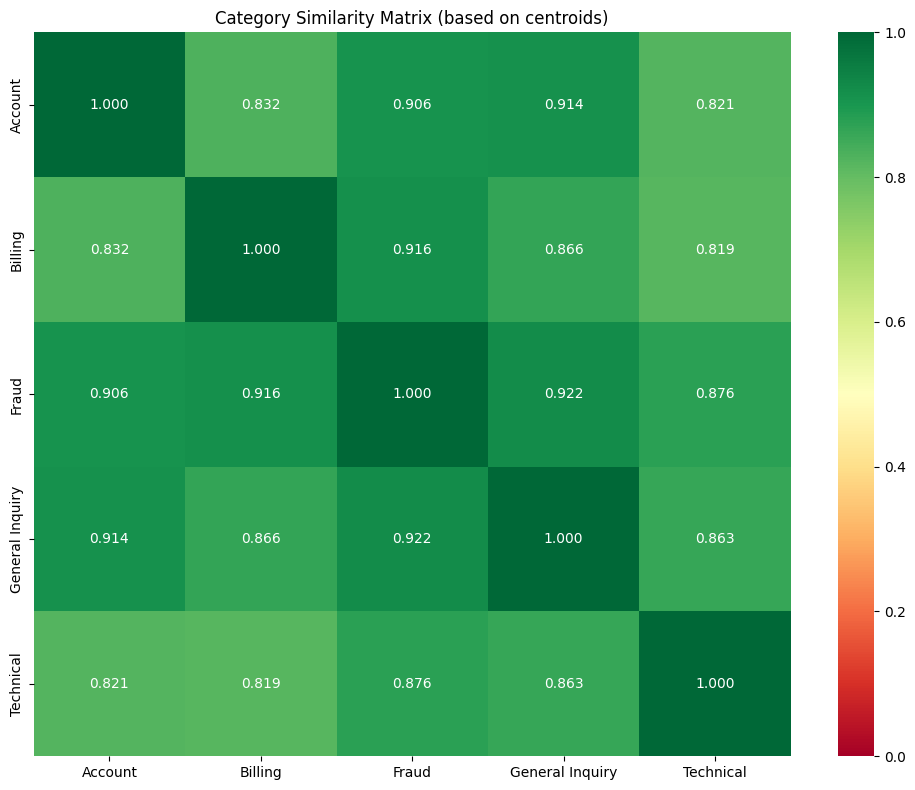


Most similar category pairs:
  Account ↔ Billing: 0.8317
  Account ↔ Fraud: 0.9064
  Account ↔ General Inquiry: 0.9139
  Account ↔ Technical: 0.8208
  Billing ↔ Fraud: 0.9163
  Billing ↔ General Inquiry: 0.8659
  Billing ↔ Technical: 0.8190
  Fraud ↔ General Inquiry: 0.9221
  Fraud ↔ Technical: 0.8759
  General Inquiry ↔ Technical: 0.8625


In [13]:
# Category Centroids Analysis
from scipy.spatial.distance import cosine

# Calculate centroids for each category
centroids = {}
for category in class_names:
    category_mask = metadata['Issue_Category'] == category
    category_indices = np.where(category_mask)[0]
    if len(category_indices) > 0:
        category_embeddings = embeddings[category_indices]
        centroids[category] = np.mean(category_embeddings, axis=0)

print("Category Centroids Computed")

# Find closest categories to each other
print("\n=== Category Similarity Matrix ===")
similarity_matrix = np.zeros((len(class_names), len(class_names)))
for i, cat1 in enumerate(class_names):
    for j, cat2 in enumerate(class_names):
        if cat1 in centroids and cat2 in centroids:
            similarity = 1 - cosine(centroids[cat1], centroids[cat2])
            similarity_matrix[i, j] = similarity

# Display similarity matrix
plt.figure(figsize=(10, 8))
sns.heatmap(similarity_matrix, annot=True, fmt='.3f', 
            xticklabels=class_names, yticklabels=class_names, 
            cmap='RdYlGn', vmin=0, vmax=1)
plt.title('Category Similarity Matrix (based on centroids)')
plt.tight_layout()
plt.show()

# Find most similar category pairs
print("\nMost similar category pairs:")
for i in range(len(class_names)):
    for j in range(i+1, len(class_names)):
        sim = similarity_matrix[i, j]
        if sim > 0.7:  # High similarity threshold
            print(f"  {class_names[i]} ↔ {class_names[j]}: {sim:.4f}")

In [14]:
# Error Analysis for best model
y_pred = best_y_pred
misclassified_mask = y_test != y_pred
misclassified_indices = np.where(misclassified_mask)[0]

print(f"Total misclassified: {len(misclassified_indices)} out of {len(y_test)} ({len(misclassified_indices)/len(y_test)*100:.2f}%)\n")

# Show misclassified examples with context
print("=== Misclassified Examples ===")
for i in misclassified_indices[:15]:
    true_category = class_names[y_test[i]]
    pred_category = class_names[y_pred[i]]
    print(f"Example {i}: True: {true_category} → Predicted: {pred_category}")
    
    # Get confidence if available
    if hasattr(best_clf, 'predict_proba'):
        try:
            probs = best_clf.predict_proba(X_test[i:i+1])[0]
            confidence = probs[y_pred[i]]
            print(f"  Confidence: {confidence:.4f}")
        except:
            pass
    print()

# Analyze confusion by category
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print("\n=== Confusion Matrix Analysis ===")
for i, true_cat in enumerate(class_names):
    mispredicted_as = []
    for j, pred_cat in enumerate(class_names):
        if i != j and cm[i, j] > 0:
            mispredicted_as.append(f"{pred_cat}({cm[i, j]})")
    if mispredicted_as:
        print(f"{true_cat} misclassified as: {', '.join(mispredicted_as)}")

Total misclassified: 15291 out of 69370 (22.04%)

=== Misclassified Examples ===
Example 15: True: General Inquiry → Predicted: Account
  Confidence: 0.4664

Example 17: True: Billing → Predicted: Account
  Confidence: 0.3489

Example 20: True: Billing → Predicted: Technical
  Confidence: 0.9545

Example 23: True: Technical → Predicted: Account
  Confidence: 0.7144

Example 26: True: Billing → Predicted: Fraud
  Confidence: 0.5821

Example 27: True: General Inquiry → Predicted: Billing
  Confidence: 0.6046

Example 31: True: Fraud → Predicted: General Inquiry
  Confidence: 0.3674

Example 33: True: Account → Predicted: Technical
  Confidence: 0.3217

Example 36: True: Technical → Predicted: Billing
  Confidence: 0.7756

Example 50: True: Account → Predicted: General Inquiry
  Confidence: 0.5983

Example 51: True: Billing → Predicted: Account
  Confidence: 0.6598

Example 55: True: Billing → Predicted: Account
  Confidence: 0.4951

Example 57: True: Technical → Predicted: General Inquir

=== Performance by Category ===
       Category  Precision   Recall  F1-Score  Support
        Account   0.824461 0.857160  0.840493    24482
        Billing   0.795267 0.754430  0.774310    11626
      Technical   0.760311 0.781306  0.770666    16658
General Inquiry   0.721766 0.741274  0.731390    14096
          Fraud   0.664346 0.342504  0.451986     2508


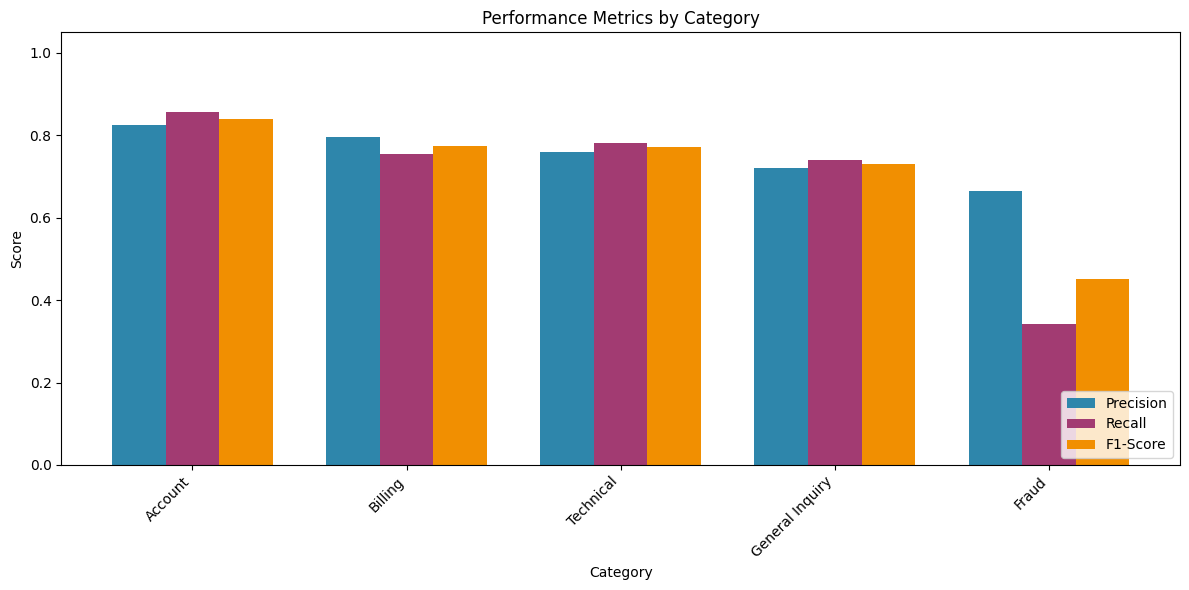

In [15]:
# Performance by Category
from sklearn.metrics import precision_recall_fscore_support

# Calculate per-class metrics
precision, recall, f1, support = precision_recall_fscore_support(y_test, y_pred)

metrics_df = pd.DataFrame({
    'Category': class_names,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1,
    'Support': support
})

print("=== Performance by Category ===")
print(metrics_df.sort_values('F1-Score', ascending=False).to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
metrics_df_sorted = metrics_df.sort_values('F1-Score', ascending=False)
x = range(len(metrics_df_sorted))
width = 0.25

ax.bar([i - width for i in x], metrics_df_sorted['Precision'], width, label='Precision', color='#2E86AB')
ax.bar(x, metrics_df_sorted['Recall'], width, label='Recall', color='#A23B72')
ax.bar([i + width for i in x], metrics_df_sorted['F1-Score'], width, label='F1-Score', color='#F18F01')

ax.set_xlabel('Category')
ax.set_ylabel('Score')
ax.set_title('Performance Metrics by Category')
ax.set_xticks(x)
ax.set_xticklabels(metrics_df_sorted['Category'], rotation=45, ha='right')
ax.legend(loc='lower right')
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

In [16]:
# Quick RAG Demo - Find similar tickets by category
def find_tickets_by_category(category, embeddings, metadata, n_samples=3):
    """
    Random sample of tickets from a specific category with similar matches
    """
    category_mask = metadata['Issue_Category'] == category
    category_indices = np.where(category_mask)[0]
    
    if len(category_indices) == 0:
        print(f"No tickets found for category: {category}")
        return
    
    # Random sample
    sample_indices = np.random.choice(category_indices, min(n_samples, len(category_indices)), replace=False)
    
    print(f"\n=== Random {category} Tickets ===")
    for idx in sample_indices:
        print(f"Ticket #{idx}")
        
        # Find similar tickets within same category
        query_embedding = embeddings[idx].reshape(1, -1)
        similarities = cosine_similarity(query_embedding, embeddings[category_indices])[0]
        # Get top 3 similar (excluding itself)
        top_similar = category_indices[np.argsort(similarities)[-4:-1]][::-1]
        
        print(f"  Similar tickets in same category: {list(top_similar)}")
        print()

# Test for each category
for category in class_names:
    find_tickets_by_category(category, embeddings, metadata, n_samples=2)


=== Random Account Tickets ===
Ticket #253117
  Similar tickets in same category: [np.int64(253381), np.int64(253513), np.int64(255688)]

Ticket #264535
  Similar tickets in same category: [np.int64(87742), np.int64(68739), np.int64(166779)]


=== Random Billing Tickets ===
Ticket #134632
  Similar tickets in same category: [np.int64(319232), np.int64(264970), np.int64(155187)]

Ticket #154193
  Similar tickets in same category: [np.int64(321423), np.int64(48070), np.int64(146010)]


=== Random Fraud Tickets ===
Ticket #61779
  Similar tickets in same category: [np.int64(61247), np.int64(75252), np.int64(141219)]

Ticket #111125
  Similar tickets in same category: [np.int64(156758), np.int64(343066), np.int64(67237)]


=== Random General Inquiry Tickets ===
Ticket #142579
  Similar tickets in same category: [np.int64(270808), np.int64(92495), np.int64(115869)]

Ticket #98428
  Similar tickets in same category: [np.int64(276327), np.int64(257005), np.int64(22437)]


=== Random Technica

In [17]:
# Save Results and Models
import joblib

# Create directories if they don't exist
os.makedirs("../models", exist_ok=True)
os.makedirs("../results", exist_ok=True)

# Save the best model
model_path = "../models/best_classifier.pkl"
joblib.dump(best_clf, model_path)
print(f"✅ Best model saved to {model_path}")

# Save label encoder
encoder_path = "../models/label_encoder.pkl"
joblib.dump(label_encoder, encoder_path)
print(f"✅ Label encoder saved to {encoder_path}")

# Save results summary
summary_df = results_df_large[['Classifier', 'Accuracy', 'Train_Time']].sort_values('Accuracy', ascending=False)
summary_df.to_csv("../results/classification_results.csv", index=False)
print(f"✅ Results saved to ../results/classification_results.csv")

# Save confusion matrix
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)
cm_df.to_csv("../results/confusion_matrix.csv")
print(f"✅ Confusion matrix saved to ../results/confusion_matrix.csv")

# Save metrics by category
metrics_df.to_csv("../results/metrics_by_category.csv", index=False)
print(f"✅ Metrics by category saved to ../results/metrics_by_category.csv")

print("\n" + "="*50)
print("=== EXPERIMENT COMPLETE ===")
print("="*50)
print(f"Best accuracy: {best_result['Accuracy']:.4f} with {best_clf_name}")
print(f"Total samples: {len(y_test)}")
print(f"Misclassification rate: {len(misclassified_indices)/len(y_test)*100:.2f}%")

✅ Best model saved to ../models/best_classifier.pkl
✅ Label encoder saved to ../models/label_encoder.pkl
✅ Results saved to ../results/classification_results.csv
✅ Confusion matrix saved to ../results/confusion_matrix.csv
✅ Metrics by category saved to ../results/metrics_by_category.csv

=== EXPERIMENT COMPLETE ===
Best accuracy: 0.7796 with Logistic Regression
Total samples: 69370
Misclassification rate: 22.04%
